Célula 1 — Imports e carregar os dados:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/mapas_raw.csv")
print(f"Total de linhas: {len(df)}")
df.head()

Total de linhas: 6822


,mapstat_id,timestamp_unix,team1_id,team1_nome,team1_score,team2_id,team2_nome,team2_score,vencedor,mapa,evento_id,evento_nome
0,236101,1787841000000,13286,FUT,11,12468,Legacy,13,Legacy,Dust2,8249,BLAST Open Porto 2026
1,236091,1787841000000,12468,Legacy,13,13286,FUT,10,Legacy,Ancient,8249,BLAST Open Porto 2026
2,236076,1787832000000,9996,9z,7,4494,MOUZ,13,MOUZ,Nuke,8249,BLAST Open Porto 2026
3,236067,1787832000000,4494,MOUZ,13,9996,9z,4,MOUZ,Cache,8249,BLAST Open Porto 2026
4,236058,1787821200000,13117,Inner Circle,16,9565,Vitality,13,Inner Circle,Cache,8249,BLAST Open Porto 2026


Célula 2 — Verificar duplicados e valores em falta:

In [2]:
print("Duplicados (por mapstat_id):", df.duplicated(subset="mapstat_id").sum())
print("\nValores em falta por coluna:")
print(df.isnull().sum())

Duplicados (por mapstat_id): 0

Valores em falta por coluna:
mapstat_id        0
timestamp_unix    0
team1_id          0
team1_nome        0
team1_score       0
team2_id          0
team2_nome        0
team2_score       0
vencedor          0
mapa              0
evento_id         0
evento_nome       0
dtype: int64


Célula 3 — Converter timestamp para data legível:

In [3]:
# O timestamp_unix esta em milissegundos, por isso dividimos por 1000
df["data"] = pd.to_datetime(df["timestamp_unix"], unit="ms")
df[["mapstat_id", "data", "team1_nome", "team2_nome"]].head()

,mapstat_id,data,team1_nome,team2_nome
0,236101,2026-08-27 14:30:00,FUT,Legacy
1,236091,2026-08-27 14:30:00,Legacy,FUT
2,236076,2026-08-27 12:00:00,9z,MOUZ
3,236067,2026-08-27 12:00:00,MOUZ,9z
4,236058,2026-08-27 09:00:00,Inner Circle,Vitality


Célula 4 — Quantas equipas distintas e intervalo temporal:

In [4]:
equipas = pd.concat([df["team1_nome"], df["team2_nome"]]).unique()
print(f"Numero de equipas distintas: {len(equipas)}")
print(f"\nIntervalo de datas: {df['data'].min()} ate {df['data'].max()}")

Numero de equipas distintas: 84

Intervalo de datas: 2023-10-04 16:00:00 ate 2026-08-27 14:30:00


Célula 5 — Quantos mapas por equipa (top 15):
Isto é importante: equipas com poucos jogos no dataset vão ter previsões pouco fiáveis.

In [5]:
jogos_por_equipa = pd.concat([df["team1_nome"], df["team2_nome"]]).value_counts()
jogos_por_equipa.head(15)

FaZe             513
FURIA            506
MOUZ             494
G2               489
Vitality         464
Natus Vincere    464
Spirit           457
Astralis         456
The MongolZ      452
HEROIC           448
Falcons          433
3DMAX            429
paiN             392
Aurora           383
GamerLegion      367
Name: count, dtype: int64

Célula 6 — Distribuição de jogos por equipa (histograma):

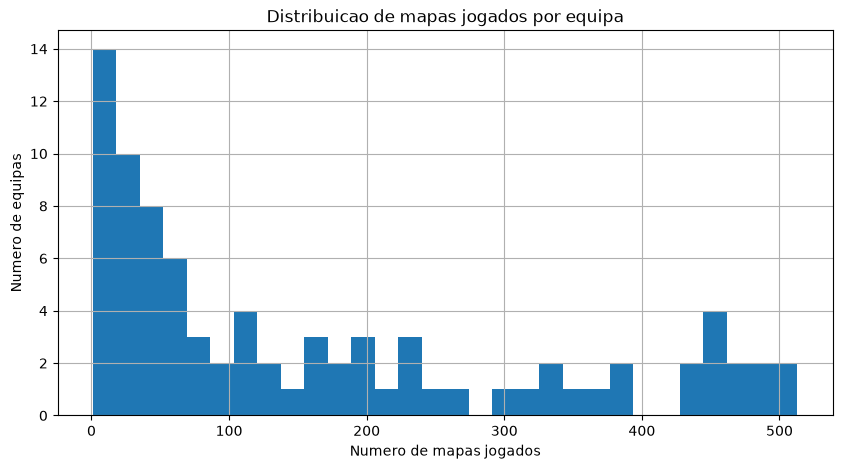

In [6]:
plt.figure(figsize=(10, 5))
jogos_por_equipa.hist(bins=30)
plt.xlabel("Numero de mapas jogados")
plt.ylabel("Numero de equipas")
plt.title("Distribuicao de mapas jogados por equipa")
plt.show()

Célula 7 — Winrate por mapa (qual mapa é mais equilibrado/desequilibrado):

In [7]:
# Contar quantas vezes cada mapa foi jogado
print("Mapas jogados:")
print(df["mapa"].value_counts())

Mapas jogados:
mapa
Mirage      1117
Ancient     1098
Nuke        1069
Inferno      941
Dust2        905
Anubis       671
Overpass     450
Vertigo      304
Train        232
Cache         35
Name: count, dtype: int64


Célula 8

In [8]:
df_matches = pd.read_csv("../data/matches_clean.csv")
df_matches["data"] = pd.to_datetime(df_matches["data"])

print(f"Total de matches: {len(df_matches)}")
print(f"\nDistribuicao de formato (num_mapas):")
print(df_matches["num_mapas"].value_counts())

Total de matches: 3020

Distribuicao de formato (num_mapas):
num_mapas
2    1383
3    1135
1     461
4      25
5      16
Name: count, dtype: int64


Célula 9 — verificar se há viés estrutural entre "team_a" e "team_b":

In [9]:
# Como "team_a" e so a primeira equipa que apareceu nos dados,
# nao deveria haver vantagem sistematica em ser "a" ou "b".
# Isto e importante confirmar, porque se houver um viés aqui,
# pode ser um sinal de bug na reconstrucao dos matches.
vitorias_a = (df_matches["vencedor_id"] == df_matches["team_a_id"]).sum()
vitorias_b = len(df_matches) - vitorias_a
print(f"Vitorias da equipa 'a': {vitorias_a} ({vitorias_a/len(df_matches)*100:.1f}%)")
print(f"Vitorias da equipa 'b': {vitorias_b} ({vitorias_b/len(df_matches)*100:.1f}%)")

Vitorias da equipa 'a': 1425 (47.2%)
Vitorias da equipa 'b': 1595 (52.8%)


In [10]:
df_matches = pd.read_csv("../data/matches_clean.csv")

# Ver os matches com numero de mapas impossivel (so pode ser 1, 2, 3 ou 5)
suspeitos = df_matches[df_matches["num_mapas"].isin([4, 6])]
print(f"Total de casos suspeitos: {len(suspeitos)}")
suspeitos.head(3)

Total de casos suspeitos: 25


,match_id,data,evento_id,evento_nome,team_a_id,team_a_nome,team_b_id,team_b_nome,mapas_ganhos_a,mapas_ganhos_b,num_mapas,mapas_jogados,mapstat_ids,vencedor_id,vencedor_nome
171,2969,2023-12-03 15:00:00,7250,Elisa Masters Espoo 2023,9806,Apeks,8297,FURIA,1,3,4,"Mirage,Vertigo,Ancient,Inferno","167587,167583,167580,167577",8297,FURIA
195,2078,2023-12-10 12:00:00,7359,ESL Challenger League Season 46 Asia-Pacific,4863,TYLOO,6248,The MongolZ,1,3,4,"Inferno,Anubis,Mirage,Nuke","168025,168019,168014,168009",6248,The MongolZ
566,58,2024-04-14 14:30:00,7711,Skyesports Masters 2024,10503,OG,11861,Aurora,1,3,4,"Overpass,Ancient,Mirage,Anubis","173536,173532,173529,173525",11861,Aurora


In [11]:
# Substitui pelos IDs reais que apareceram na celula anterior
ids_para_investigar = suspeitos.iloc[0]["mapstat_ids"].split(",")

df_mapas = pd.read_csv("../data/mapas_raw.csv")
df_mapas[df_mapas["mapstat_id"].astype(str).isin(ids_para_investigar)].sort_values("timestamp_unix")

,mapstat_id,timestamp_unix,team1_id,team1_nome,team1_score,team2_id,team2_nome,team2_score,vencedor,mapa,evento_id,evento_nome
6423,167587,1701615600000,9806,Apeks,9,8297,FURIA,13,FURIA,Mirage,7250,Elisa Masters Espoo 2023
6424,167583,1701615600000,9806,Apeks,9,8297,FURIA,13,FURIA,Vertigo,7250,Elisa Masters Espoo 2023
6425,167580,1701615600000,9806,Apeks,13,8297,FURIA,7,Apeks,Ancient,7250,Elisa Masters Espoo 2023
6426,167577,1701615600000,8297,FURIA,13,9806,Apeks,9,FURIA,Inferno,7250,Elisa Masters Espoo 2023


In [12]:
empates = df_matches[df_matches["mapas_ganhos_a"] == df_matches["mapas_ganhos_b"]]
print(f"Matches empatados (deveria ser 0): {len(empates)}")

Matches empatados (deveria ser 0): 0


In [13]:
empates = df_matches[df_matches["mapas_ganhos_a"] == df_matches["mapas_ganhos_b"]]
empates

,match_id,data,evento_id,evento_nome,team_a_id,team_a_nome,team_b_id,team_b_nome,mapas_ganhos_a,mapas_ganhos_b,num_mapas,mapas_jogados,mapstat_ids,vencedor_id,vencedor_nome


In [14]:
ids_para_investigar = empates.iloc[0]["mapstat_ids"].split(",")
df_mapas[df_mapas["mapstat_id"].astype(str).isin(ids_para_investigar)].sort_values("timestamp_unix")

IndexError: single positional indexer is out-of-bounds

Célula 10 — carregar e ver valores em falta:

In [15]:
df_feat = pd.read_csv("../data/features_dataset.csv")
print(df_feat.isnull().sum().sum())  # deve dar 0
df_feat.head()

0


,match_id,data,team_a_nome,team_b_nome,elo_a,elo_b,elo_diferenca,forma_recente_a,forma_recente_b,jogos_historico_a,...,h2h_winrate_a,h2h_jogos,winrate_mapa_a,winrate_mapa_b,team_a_venceu,forma_recente_a_tinha_dados,forma_recente_b_tinha_dados,h2h_winrate_a_tinha_dados,winrate_mapa_a_tinha_dados,winrate_mapa_b_tinha_dados
0,630,2023-10-04 16:00:00,Looking4Org,Bad News Eagles,1500.000000,1500.0,0.000000,0.5,0.5,0,...,0.5,0,0.5,0.5,1,0,0,0,0,0
1,1006,2023-10-09 13:30:00,Looking4Org,Spirit,1516.000000,1500.0,16.000000,1.0,0.5,1,...,0.5,0,1.0,0.5,0,1,0,0,1,0
2,919,2023-10-09 13:30:00,Aurora,Apeks,1500.000000,1500.0,0.000000,0.5,0.5,0,...,0.5,0,0.5,0.5,0,0,0,0,0,0
3,1008,2023-10-09 18:00:00,Looking4Org,BIG,1499.263693,1500.0,-0.736307,0.5,0.5,2,...,0.5,0,0.5,0.5,1,1,0,0,1,0
4,2930,2023-10-09 18:00:00,Apeks,Movistar Riders,1516.000000,1500.0,16.000000,1.0,0.5,1,...,0.5,0,1.0,0.5,0,1,0,0,1,0


Célula 11 — verificar se o Elo das equipas top é mesmo mais alto:

In [16]:
# Para cada equipa, vemos o Elo dela no jogo mais recente em que apareceu
equipas_para_verificar = ["FaZe", "Vitality", "MOUZ", "G2", "Apeks", "Movistar Riders"]

for equipa in equipas_para_verificar:
    jogos_equipa = df_feat[
        (df_feat["team_a_nome"] == equipa) | (df_feat["team_b_nome"] == equipa)
    ].sort_values("data")

    if len(jogos_equipa) == 0:
        print(f"{equipa}: sem jogos encontrados")
        continue

    ultimo_jogo = jogos_equipa.iloc[-1]
    elo_atual = (ultimo_jogo["elo_a"] if ultimo_jogo["team_a_nome"] == equipa
                 else ultimo_jogo["elo_b"])
    print(f"{equipa}: Elo = {elo_atual:.0f} (baseado em {len(jogos_equipa)} jogos)")

FaZe: Elo = 1558 (baseado em 228 jogos)
Vitality: Elo = 1829 (baseado em 194 jogos)
MOUZ: Elo = 1698 (baseado em 210 jogos)
G2: Elo = 1628 (baseado em 209 jogos)
Apeks: Elo = 1458 (baseado em 53 jogos)
Movistar Riders: Elo = 1471 (baseado em 15 jogos)


Célula 12 — verificar se maior diferença de Elo prevê melhor a vitória (correlação básica):

In [17]:
# Agrupamos os jogos por "faixas" de diferenca de Elo, e vemos
# se a equipa favorita (elo_diferenca positivo) ganha mais vezes
# a medida que a vantagem de Elo aumenta.
df_feat["faixa_elo"] = pd.cut(df_feat["elo_diferenca"], bins=[-1000, -200, -50, 50, 200, 1000])
print(df_feat.groupby("faixa_elo", observed=True)["team_a_venceu"].agg(["mean", "count"]))

                   mean  count
faixa_elo                     
(-1000, -200]  0.191111    225
(-200, -50]    0.365854    820
(-50, 50]      0.494515   1185
(50, 200]      0.598174    657
(200, 1000]    0.774436    133


In [18]:
import sys
sys.path.append("../src/models")
from train_baseline import treinar_e_avaliar

modelo, teste, previsoes, probabilidades = treinar_e_avaliar()

Treino: 2416 jogos (2023-10-04 a 2026-02-01)
Teste:  604 jogos (2026-02-02 a 2026-08-27)

Features usadas (14): ['elo_diferenca', 'forma_recente_a', 'forma_recente_b', 'jogos_historico_a', 'jogos_historico_b', 'h2h_winrate_a', 'h2h_jogos', 'winrate_mapa_a', 'winrate_mapa_b', 'forma_recente_a_tinha_dados', 'forma_recente_b_tinha_dados', 'h2h_winrate_a_tinha_dados', 'winrate_mapa_a_tinha_dados', 'winrate_mapa_b_tinha_dados']

Baseline ingenuo (Elo mais alto ganha sempre): accuracy = 0.613

=== Resultados do modelo (Regressao Logistica) ===
Accuracy: 0.632
Log Loss: 0.645

Relatorio detalhado:
               precision    recall  f1-score   support

team_b_venceu       0.65      0.70      0.67       326
team_a_venceu       0.61      0.56      0.58       278

     accuracy                           0.63       604
    macro avg       0.63      0.63      0.63       604
 weighted avg       0.63      0.63      0.63       604


Importancia das features (maior valor absoluto = mais influente):
  

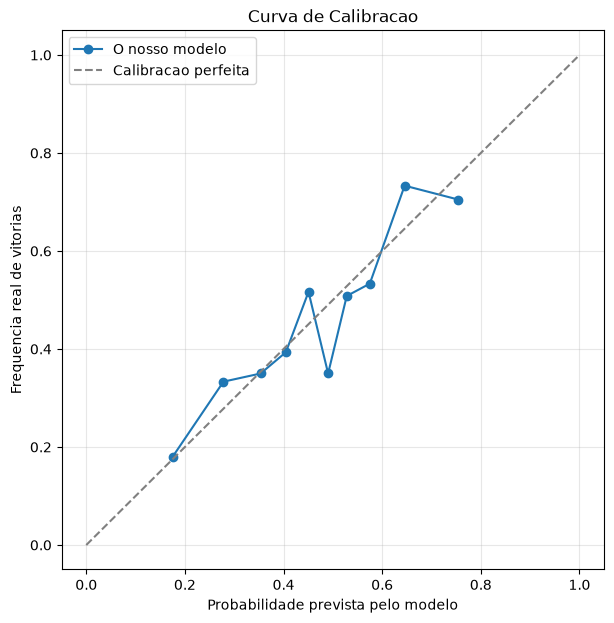

In [19]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# "prob_verdadeira" = fracao real de vitorias em cada faixa de probabilidade
# "prob_prevista" = o valor medio de probabilidade que o modelo atribuiu nessa faixa
prob_verdadeira, prob_prevista = calibration_curve(
    teste["team_a_venceu"], probabilidades, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 7))
plt.plot(prob_prevista, prob_verdadeira, marker="o", label="O nosso modelo")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibracao perfeita")
plt.xlabel("Probabilidade prevista pelo modelo")
plt.ylabel("Frequencia real de vitorias")
plt.title("Curva de Calibracao")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(teste["team_a_venceu"], probabilidades)
print(f"Brier Score: {brier:.4f}")
print(f"(Para comparacao: adivinhar sempre 50% daria {0.5**2:.4f})")

Brier Score: 0.2259
(Para comparacao: adivinhar sempre 50% daria 0.2500)
